In [41]:
# %matplotlib macosx
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from optim import SSBFGS, SSBroyden
import scipy.io
from scipy.interpolate import griddata

In [42]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, t):
        X = torch.cat([x, t], dim=1)
        return self.net(X)

class HardCodeNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, t):
        X = torch.cat([x, t], dim=1)
        N_out = self.net(X)

        f_i = -torch.sin(torch.pi * x) # initial condition
        h_b = t * (1 - x**2) # homogeneous part that vanishes at the boundary
        u_pred = f_i + h_b * N_out
        return u_pred

Solve the 1D Viscous Burgers' equation in a spatio-temporal domain $\Omega = [-1, 1] \times [0, 1]$
$$\begin{cases}
    \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} - \frac{0.01}{\pi} \frac{\partial^2 u}{\partial x^2} = 0 & \ \text{ in } \Omega \\
    u(x, 0) = -\sin(\pi x) & \ \text{ on } [-1, 1] \times \{0\} \\
    u(-1, t) = u(1, t) = 0 & \ \text{ on } \{-1, 1\} \times [0, 1]
\end{cases}$$


In [43]:
torch.manual_seed(42)
np.random.seed(42)

In [44]:
# --- Collocation points ---
N_f = 10000
x_f = (torch.rand(N_f, 1) * 2 - 1).requires_grad_(True)
t_f = torch.rand(N_f, 1).requires_grad_(True)

# --- Initial condition points ---
N_i = 100
x_i = torch.rand(N_i, 1) * 2 - 1
t_i = torch.zeros(N_i, 1)
f_i = (-torch.sin(torch.pi * x_i)).detach()

# --- Boundary points ---
N_b = 200
# x = -1, x = 1
x_b = torch.cat([-torch.ones(N_b//2, 1), torch.ones(N_b//2, 1)], dim=0)
t_b = torch.cat([torch.rand(N_b//2, 1), torch.rand(N_b//2, 1)], dim=0)

loss_value = {}

In [45]:
def plateau_check(loss_history, window_size=100, threshold=1e-4):
    if len(loss_history) < window_size:
        return False
    window = loss_history[-window_size:]
    rel_spread = (max(window) - min(window)) / (min(window) + 1e-12)
    return rel_spread < threshold

In [46]:
# --- Initialize the network ---
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
net = Net(layers)
optimizer = optim.Adam(net.parameters(), lr=1e-3)

loss_value["Standard"] = []

# --- Training loop ---
start = time.time()
for epoch in range(5000):
    optimizer.zero_grad()

    # Wipe the input gradients alongside the optimizer!
    if x_f.grad is not None: x_f.grad.zero_()
    if t_f.grad is not None: t_f.grad.zero_()

    # --- Compute the PDE residual ---
    u_pred = net(x_f, t_f)
    u_x = torch.autograd.grad(u_pred, x_f, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_t = torch.autograd.grad(u_pred, t_f, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]


    residual = u_t + u_pred * u_x - (0.01 / torch.pi) * u_xx
    loss_pde = torch.mean(residual**2)

    # --- Compute the initial condition loss ---
    u_i_pred = net(x_i, t_i)
    loss_ic = torch.mean((u_i_pred - f_i)**2)

    # --- Compute the boundary loss ---
    u_b_pred = net(x_b, t_b)
    loss_bc = torch.mean(u_b_pred**2)

    # --- Total loss ---
    loss = loss_pde + loss_ic + loss_bc

    # --- Backpropagation ---
    loss.backward()
    optimizer.step()

    loss_value["Standard"].append(loss.item())
    if plateau_check(loss_value["Standard"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}, PDE Loss: {loss_pde.item():.6f}, Boundary Loss: {loss_bc.item():.6f}')

print(f'Training completed in {time.time() - start:.2f} seconds')

Epoch 0, Loss: 0.529459, PDE Loss: 0.000005, Boundary Loss: 0.000383
Epoch 500, Loss: 0.088128, PDE Loss: 0.039021, Boundary Loss: 0.000804
Epoch 1000, Loss: 0.056362, PDE Loss: 0.033368, Boundary Loss: 0.000639
Epoch 1500, Loss: 0.007958, PDE Loss: 0.004756, Boundary Loss: 0.000221
Epoch 2000, Loss: 0.006379, PDE Loss: 0.004498, Boundary Loss: 0.000137
Epoch 2500, Loss: 0.004470, PDE Loss: 0.002970, Boundary Loss: 0.000137
Epoch 3000, Loss: 0.003066, PDE Loss: 0.001788, Boundary Loss: 0.000049
Epoch 3500, Loss: 0.002593, PDE Loss: 0.001719, Boundary Loss: 0.000049
Epoch 4000, Loss: 0.003936, PDE Loss: 0.003262, Boundary Loss: 0.000028
Epoch 4500, Loss: 0.001359, PDE Loss: 0.000842, Boundary Loss: 0.000026
Training completed in 233.91 seconds


In [47]:
def compute_loss(net):
    # Wipe the input gradients inside the closure!
    if x_f.grad is not None: x_f.grad.zero_()
    if t_f.grad is not None: t_f.grad.zero_()

    # PDE residual
    u_f = net(x_f, t_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_t = torch.autograd.grad(u_f.sum(), t_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u_f * u_x - (0.01 / torch.pi) * u_xx
    loss_pde = torch.mean(residual**2)

    return loss_pde

In [48]:
model = HardCodeNet(layers)
loss_value["HC Boundaries"] = []
# --- Stage 1: Adam Optimizer (Initialization) ---
print("Stage 1: Pre-training with Adam...")
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)

start = time.time()
for epoch in range(2000): # Adam iterations
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    loss_value["HC Boundaries"].append(loss.item())
    if plateau_check(loss_value["HC Boundaries"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

adam_time = time.time() - start

Stage 1: Pre-training with Adam...
Epoch 0, Loss: 1.463004e+00
Epoch 500, Loss: 2.749798e-01
Epoch 1000, Loss: 2.429162e-02
Epoch 1500, Loss: 2.383755e-01


In [49]:
model_std_lbfgs = copy.deepcopy(model) # Experiment 2
loss_value["std"] = loss_value["HC Boundaries"][:]

model_sqrt_lbfgs = copy.deepcopy(model) # Experiment 3
loss_value["sqrt"] = loss_value["HC Boundaries"][:]

model_log_lbfgs = copy.deepcopy(model) # Experiment 4
loss_value["log"] = loss_value["HC Boundaries"][:]

model_ssbfgs = copy.deepcopy(model) # Experiment 5
loss_value["ssbfgs"] = loss_value["HC Boundaries"][:]

model_ssbroyden = copy.deepcopy(model) # Experiment 6
loss_value["ssbroyden"] = loss_value["HC Boundaries"][:]

In [50]:
# --- EXPERIMENT 1: Continue with Adam (No LBFGS) ---
print("Exp 1: Continuing Adam...")
start = time.time()
for epoch in range(2000, 5000):
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    loss_value["HC Boundaries"].append(loss.item())
    if plateau_check(loss_value["HC Boundaries"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch},  Loss: {loss.item():.6e}")

print(f"Total time Adam: {adam_time + time.time() - start:.2f} seconds")

Exp 1: Continuing Adam...
Epoch 2000,  Loss: 1.283999e-02
Epoch 2500,  Loss: 1.438965e-02
Epoch 3000,  Loss: 6.882463e-03
Epoch 3500,  Loss: 6.312456e-03
Epoch 4000,  Loss: 5.046833e-03
Epoch 4500,  Loss: 5.265908e-03
Total time Adam: 234.48 seconds


In [51]:
# --- EXPERIMENT 2: Standard LBFGS (Minimize MSE) ---
print("Exp 2: Standard LBFGS (MSE)...")
opt_std = optim.LBFGS(
    model_std_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

lbfgs_epochs = 2000

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_std():
        opt_std.zero_grad()
        loss = compute_loss(model_std_lbfgs) # Standard Loss
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_std.step(closure_std)

    loss_value["std"].append(loss_val.item())
    if plateau_check(loss_value["std"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        # current_loss = closure_std().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

lbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + LBFGS): {lbfgs_time:.2f} seconds")

Exp 2: Standard LBFGS (MSE)...
L-BFGS Epoch 0, Loss: 1.283999e-02
L-BFGS Epoch 500, Loss: 8.227078e-04
L-BFGS Epoch 1000, Loss: 2.335593e-04
L-BFGS Epoch 1500, Loss: 1.269717e-04
Total time (Adam + LBFGS): 295.70 seconds


In [52]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize Sqrt(MSE)) ---
print("Exp 3: Modified LBFGS (J_1/2)...")
opt_sqrt = optim.LBFGS(
    model_sqrt_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_sqrt():
        opt_sqrt.zero_grad()
        loss_mse = compute_loss(model_sqrt_lbfgs)
        loss_sqrt = torch.sqrt(loss_mse)
        loss_sqrt.backward()
        return loss_sqrt

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_sqrt.step(closure_sqrt)

    loss_value["sqrt"].append(math.pow(loss_val.item(), 2))
    if plateau_check(loss_value["sqrt"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        # current_loss = closure_sqrt().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.pow(loss_val.item(), 2):.6e}")

sqrt_time = adam_time + time.time() - start
print(f"Total time (Adam + sqrt LBFGS): {sqrt_time:.2f} seconds")

Exp 3: Modified LBFGS (J_1/2)...
L-BFGS Epoch 0, Loss: 1.283999e-02
L-BFGS Epoch 500, Loss: 8.042798e-04
L-BFGS Epoch 1000, Loss: 2.487265e-04
L-BFGS Epoch 1500, Loss: 1.345294e-04
Total time (Adam + sqrt LBFGS): 601.33 seconds


In [53]:
# --- EXPERIMENT 4: Modified LBFGS (Minimize log(MSE)) ---
print("Exp 4: Modified LBFGS (log(J))...")
opt_log = optim.LBFGS(
    model_log_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_log():
        opt_log.zero_grad()
        loss_mse = compute_loss(model_log_lbfgs)
        loss_log = torch.log(loss_mse)
        loss_log.backward()
        return loss_log

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_log.step(closure_log)

    loss_value["log"].append(math.exp(loss_val.item()))
    if plateau_check(loss_value["log"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        # current_loss = closure_log().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.exp(loss_val.item()):.6e}")

log_time = adam_time + time.time() - start
print(f"Total time (Adam + log LBFGS): {log_time:.2f} seconds")

Exp 4: Modified LBFGS (log(J))...
L-BFGS Epoch 0, Loss: 1.283999e-02
L-BFGS Epoch 500, Loss: 7.520925e-04
L-BFGS Epoch 1000, Loss: 2.399568e-04
L-BFGS Epoch 1500, Loss: 1.291444e-04
Total time (Adam + log LBFGS): 298.40 seconds


In [54]:
# --- EXPERIMENT 5: Modified BFGS (SSBFGS) ---
print("Exp 5: SSBFGS...")
opt_ssbfgs = SSBFGS(
    model_ssbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbfgs():
        opt_ssbfgs.zero_grad()
        loss = compute_loss(model_ssbfgs)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_ssbfgs.step(closure_ssbfgs)

    loss_value["ssbfgs"].append(loss_val.item())
    if plateau_check(loss_value["ssbfgs"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbfgs().item()
        print(f"SSBFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBFGS): {ssbfgs_time:.2f} seconds")

Exp 5: SSBFGS...
SSBFGS Epoch 0, Loss: 1.283295e-02
SSBFGS Epoch 500, Loss: 6.119646e-06
SSBFGS Epoch 1000, Loss: 2.792813e-07
SSBFGS Epoch 1500, Loss: 3.967805e-08
Total time (Adam + SSBFGS): 652.68 seconds


In [55]:
# --- EXPERIMENT 6: Modified Broyden (SSBroyden) ---
print("Exp 6: SSBroyden...")
opt_ssbroyden = SSBroyden(
    model_ssbroyden.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbroyden():
        opt_ssbroyden.zero_grad()
        loss = compute_loss(model_ssbroyden)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_ssbroyden.step(closure_ssbroyden)

    loss_value["ssbroyden"].append(loss_val.item())
    if plateau_check(loss_value["ssbroyden"]):
        print(f"Plateau detected at epoch {epoch}. Stopping pre-training.")
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbroyden().item()
        print(f"SSBroyden Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbroyden_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBroyden): {ssbroyden_time:.2f} seconds")

Exp 6: SSBroyden...
SSBroyden Epoch 0, Loss: 1.283295e-02
SSBroyden Epoch 500, Loss: 3.959892e-06
SSBroyden Epoch 1000, Loss: 1.483238e-07
SSBroyden Epoch 1500, Loss: 2.095830e-08
Total time (Adam + SSBroyden): 803.20 seconds


In [56]:
x = torch.linspace(-1, 1, 100).reshape(-1, 1)
t = torch.linspace(0, 1, 100).reshape(-1, 1)
X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')
data = scipy.io.loadmat('burgers_shock.mat')

x_ref = data['x'].flatten()    # Reference spatial points (256,)
t_ref = data['t'].flatten()    # Reference temporal points (100,)
u_ref = np.real(data['usol'])  # Reference solution (256, 100)

X_ref_mesh, T_ref_mesh = np.meshgrid(x_ref, t_ref, indexing='ij')

u_exact_vis = griddata(
    (X_ref_mesh.flatten(), T_ref_mesh.flatten()),
    u_ref.flatten(),
    (X.cpu().numpy(), T.cpu().numpy()),
    method='cubic'
)

u_exact_vis = torch.tensor(u_exact_vis, dtype=torch.float32)

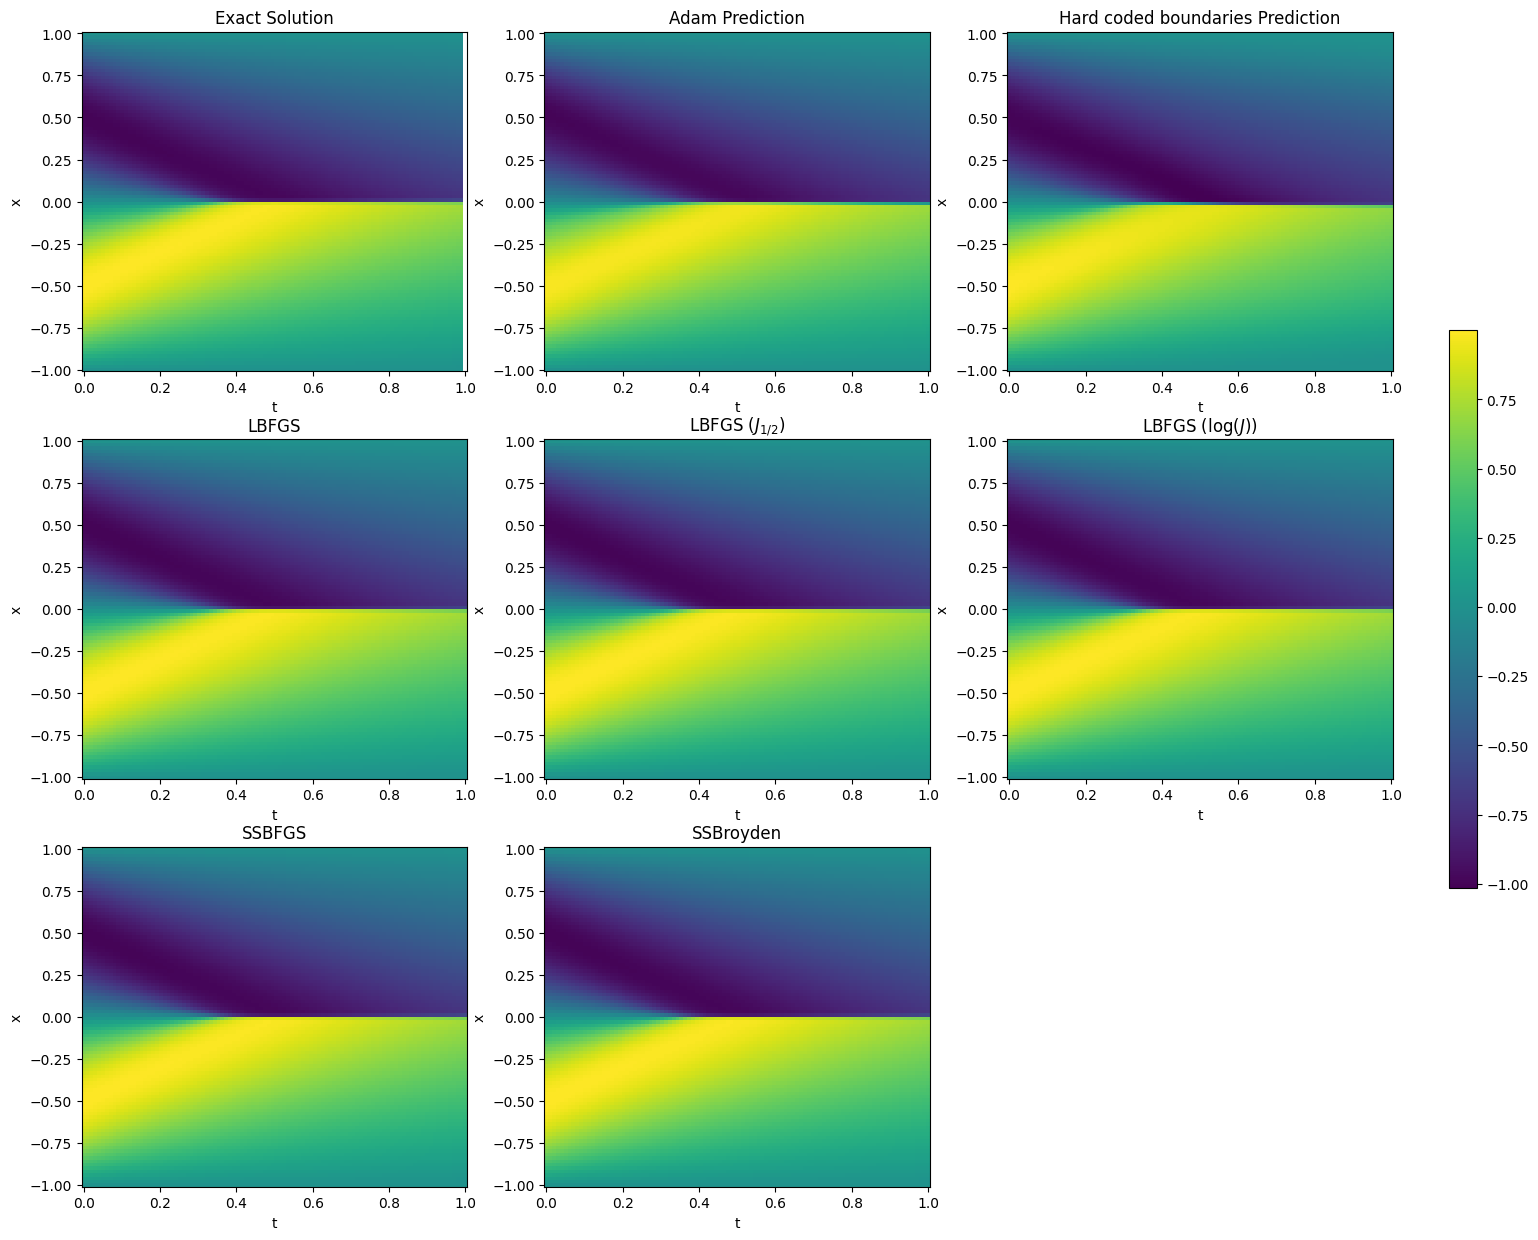

In [57]:
# --- Evaluation ---
X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

with torch.no_grad():
    u_pred = net(X_flat, T_flat).reshape(100,100)
    u_pred_hc = model(X_flat, T_flat).reshape(100,100)
    u_pred_std = model_std_lbfgs(X_flat, T_flat).reshape(100, 100)
    u_pred_sqrt = model_sqrt_lbfgs(X_flat, T_flat).reshape(100, 100)
    u_pred_log = model_log_lbfgs(X_flat, T_flat).reshape(100, 100)
    u_pred_ssbfgs = model_ssbfgs(X_flat, T_flat).reshape(100, 100)
    u_pred_ssbroyden = model_ssbroyden(X_flat, T_flat).reshape(100, 100)


all_data = [u_exact_vis, u_pred, u_pred_hc, u_pred_std, u_pred_sqrt, u_pred_log, u_pred_ssbfgs, u_pred_ssbroyden]
vmin = min(d[~torch.isnan(d)].min().item() for d in all_data)
vmax = max(d[~torch.isnan(d)].max().item() for d in all_data)

fig = plt.figure(figsize=(18,15))

# Exact solution
plt.subplot(3,3,1)
im = plt.pcolormesh(T, X, u_exact_vis, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Exact Solution')
plt.xlabel('t')
plt.ylabel('x')

# PINN prediction
plt.subplot(3,3,2)
im = plt.pcolormesh(T, X, u_pred, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Adam Prediction')
plt.xlabel('t')
plt.ylabel('x')

# Hard coded boundaries prediction
plt.subplot(3,3,3)
plt.pcolormesh(T, X, u_pred_hc, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Hard coded boundaries Prediction')
plt.xlabel('t')
plt.ylabel('x')

# Standard LBFGS prediction
plt.subplot(3,3,4)
plt.pcolormesh(T, X, u_pred_std, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('LBFGS')
plt.xlabel('t')
plt.ylabel('x')

# Sqrt LBFGS prediction
plt.subplot(3,3,5)
plt.pcolormesh(T, X, u_pred_sqrt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($J_{1/2}$)')
plt.xlabel('t')
plt.ylabel('x')

# Log LBFGS prediction
plt.subplot(3,3,6)
plt.pcolormesh(T, X, u_pred_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($\log(J)$)')
plt.xlabel('t')
plt.ylabel('x')

# Sqrt SSBFGS prediction
plt.subplot(3,3,7)
plt.pcolormesh(T, X, u_pred_ssbfgs, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBFGS')
plt.xlabel('t')
plt.ylabel('x')

# Log SSBroyden prediction
plt.subplot(3,3,8)
plt.pcolormesh(T, X, u_pred_ssbroyden, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBroyden')
plt.xlabel('t')
plt.ylabel('x')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

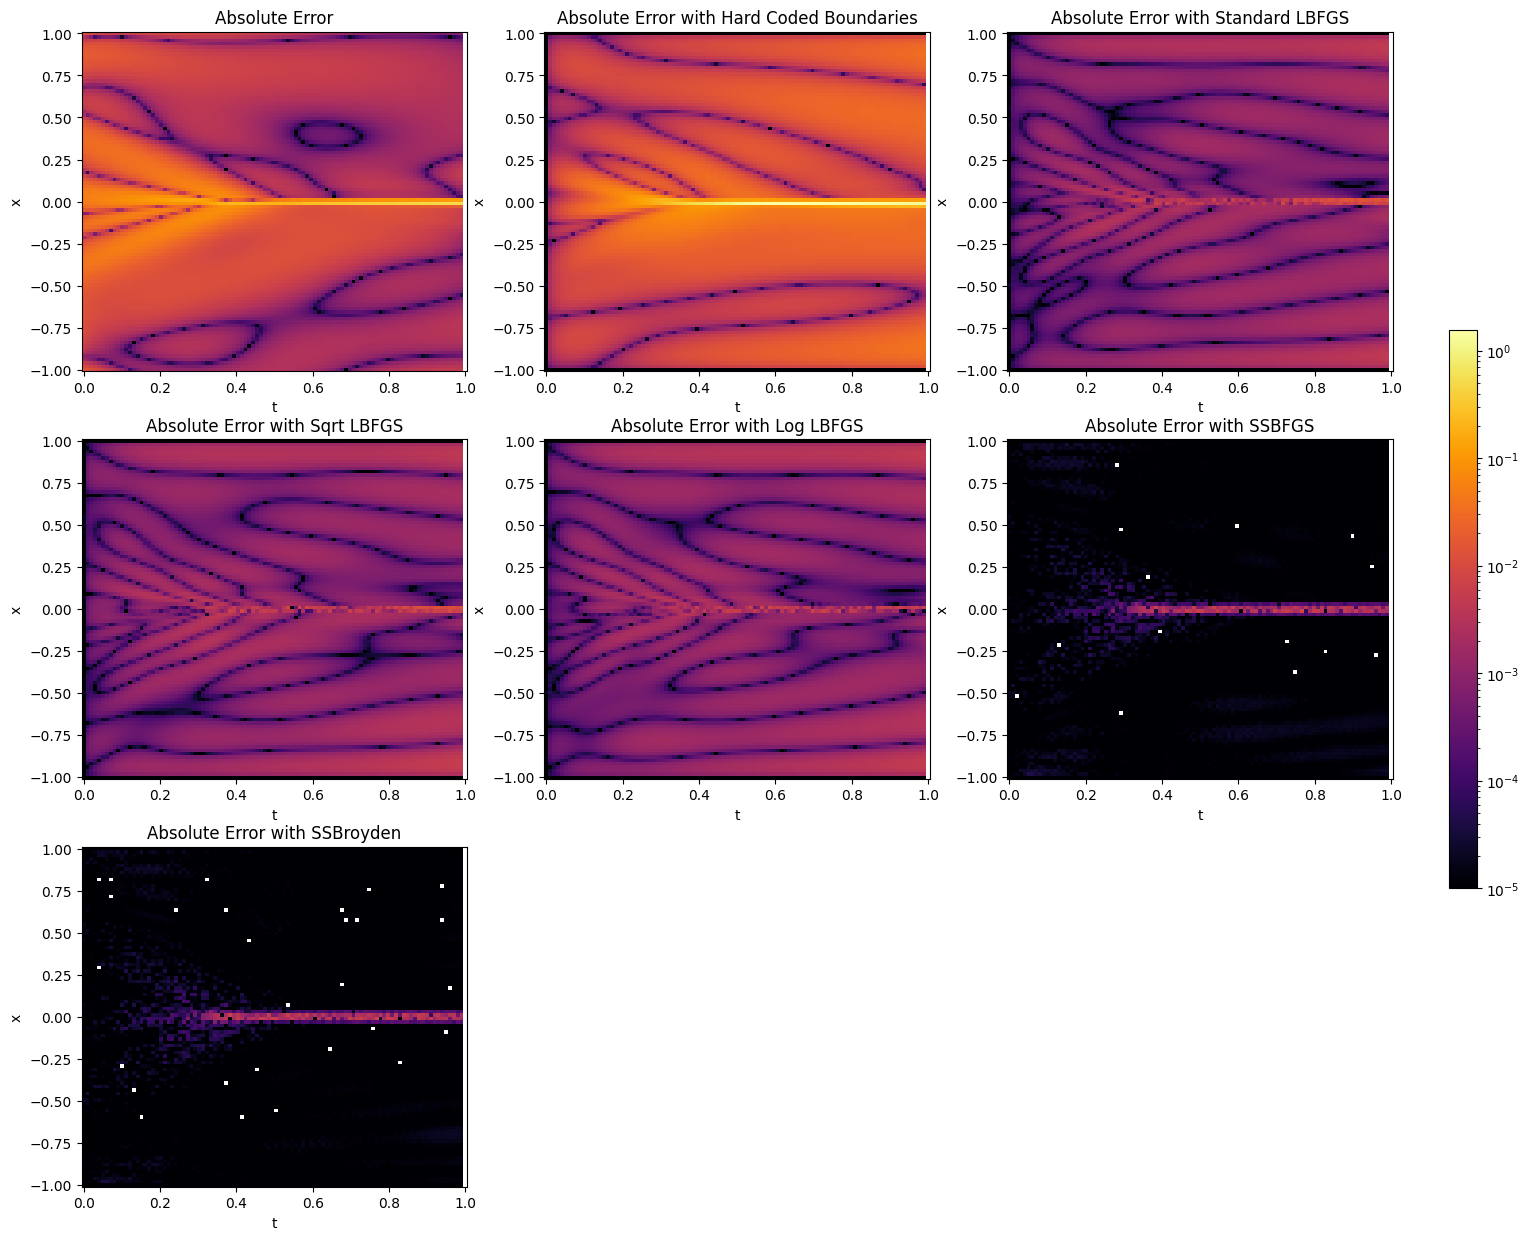

In [58]:
err_adam = torch.abs(u_pred - u_exact_vis)
err_hc = torch.abs(u_pred_hc - u_exact_vis)
err_std  = torch.abs(u_pred_std - u_exact_vis)
err_sqrt = torch.abs(u_pred_sqrt - u_exact_vis)
err_log  = torch.abs(u_pred_log - u_exact_vis)
err_ssbfgs = torch.abs(u_pred_ssbfgs - u_exact_vis)
err_ssbroyden  = torch.abs(u_pred_ssbroyden - u_exact_vis)

all_errors = [err_adam, err_hc, err_std, err_sqrt, err_log, err_ssbfgs, err_ssbroyden]
vmin_log = 1e-5
vmax = max(e[~torch.isnan(e)].max().item() for e in all_errors)

fig = plt.figure(figsize=(18,15))

plt.subplot(3,3,1)
im = plt.pcolormesh(T, X, err_adam, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(3,3,2)
plt.pcolormesh(T, X, err_hc, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Hard Coded Boundaries')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(3,3,3)
plt.pcolormesh(T, X, err_std, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Standard LBFGS')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(3,3,4)
plt.pcolormesh(T, X, err_sqrt, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Sqrt LBFGS')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(3,3,5)
plt.pcolormesh(T, X, err_log, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Log LBFGS')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(3,3,6)
plt.pcolormesh(T, X, err_ssbfgs, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBFGS')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(3,3,7)
plt.pcolormesh(T, X, err_ssbroyden, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBroyden')
plt.xlabel('t')
plt.ylabel('x')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

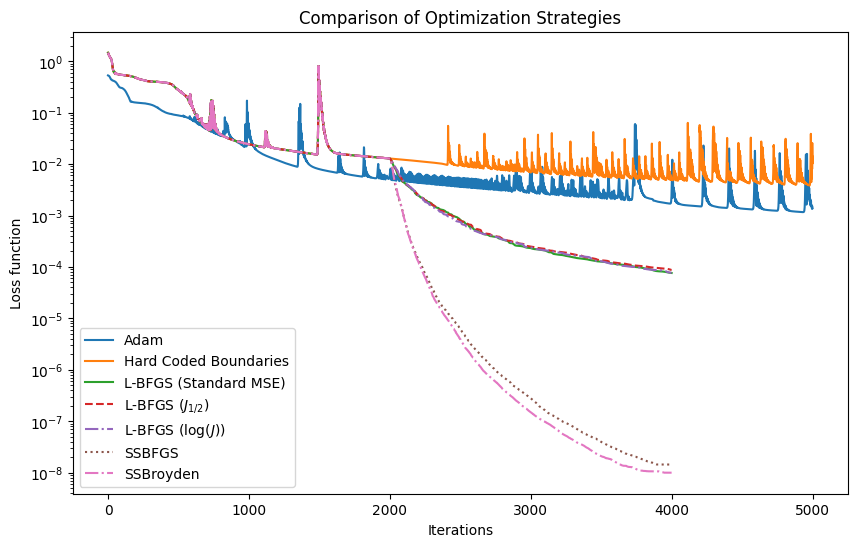

In [59]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(loss_value["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(loss_value["HC Boundaries"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(loss_value["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(loss_value["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(loss_value["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(loss_value["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(loss_value["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'Loss function')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

In [60]:
mse_adam = torch.mean(err_adam[~torch.isnan(err_adam)] ** 2)
mse_hc = torch.mean(err_hc[~torch.isnan(err_hc)] ** 2)
mse_std = torch.mean(err_std[~torch.isnan(err_std)] ** 2)
mse_sqrt = torch.mean(err_sqrt[~torch.isnan(err_sqrt)] ** 2)
mse_log = torch.mean(err_log[~torch.isnan(err_log)] ** 2)
mse_ssbfgs = torch.mean(err_ssbfgs[~torch.isnan(err_ssbfgs)] ** 2)
mse_ssbroyden = torch.mean(err_ssbroyden[~torch.isnan(err_ssbroyden)] ** 2)


print("MSE:")
print(f"Adam: {mse_adam:.6e}")
print(f"HC Boundaries: {mse_hc:.6e}")
print(f"LBFGS: {mse_std:.6e}")
print(f"LBFGS J_1/2: {mse_sqrt:.6e}")
print(f"LBFGS log(J): {mse_log:.6e}")
print(f"SSBFGS: {mse_ssbfgs:.6e}")
print(f"SSBroyden: {mse_ssbroyden:.6e}")

MSE:
Adam: 1.087912e-03
HC Boundaries: 1.126483e-02
LBFGS: 2.012451e-06
LBFGS J_1/2: 2.162031e-06
LBFGS log(J): 1.773313e-06
SSBFGS: 1.344517e-07
SSBroyden: 1.342711e-07
